# **Import Library**

In [1]:
import tensorflow as tf

import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud
import nltk

import csv
import requests
from io import StringIO

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Loading Dataset**

In [3]:
# Memuat data hasil scraping aplikasi SeaBank
app_reviews_df = pd.read_csv("https://drive.google.com/uc?id=1NGKFCUa5jDclvpY92NykAvBt7DbvsxtX")

# Menghitung jumlah baris dan kolom dalam DataFrame
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [4]:
# Menampilkan lima baris pertama dari DataFrame app_reviews_df
app_reviews_df.head()

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0,e7f67ea8-376c-4f11-860b-7cde54131967,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tempat bagus juga harga terjangkau,programnya ...",5,204,3.36.0,2026-02-01 09:36:59,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-02-01 10:25:09,3.36.0
1,1,9996cd5a-f41d-4e1e-84b2-f2665492ab32,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"TEempat bagus juga harga terjangkau,programnya...",5,14,3.37.0,2026-02-04 15:50:10,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-02-04 16:12:59,3.37.0
2,2,65c7fb0b-5cd5-45a5-8e13-6c569c76fd4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Praktis & oke juga harga,terjangkau. Programny...",5,16,3.36.0,2026-02-02 06:32:09,"Hai Sobat SeaBank, mohon maaf jika pelayanan k...",2026-02-01 06:25:31,3.36.0
3,3,9e1016ed-f492-4239-8379-aec2c0112038,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,TEmpat bagus dan praktis juga harganya terjang...,5,3,3.36.0,2026-01-23 10:19:49,"Hai Sobat SeaBank, mohon maaf. Pastikan Aplika...",2026-01-23 11:08:44,3.36.0
4,4,801799e5-c0c6-4450-a8e0-2db0efe4ccdc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Proses pendaftaran sangat mudah & cepat hanya ...,5,30,3.36.0,2026-01-28 06:33:38,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-01-28 08:26:26,3.36.0


In [5]:
# Menampilkan informasi dataframe
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238500 entries, 0 to 238499
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            238500 non-null  int64 
 1   reviewId              238500 non-null  object
 2   userName              238500 non-null  object
 3   userImage             238500 non-null  object
 4   content               238499 non-null  object
 5   score                 238500 non-null  int64 
 6   thumbsUpCount         238500 non-null  int64 
 7   reviewCreatedVersion  220106 non-null  object
 8   at                    238500 non-null  object
 9   replyContent          68598 non-null   object
 10  repliedAt             68598 non-null   object
 11  appVersion            220106 non-null  object
dtypes: int64(3), object(9)
memory usage: 21.8+ MB


In [6]:
# menghapus baris yang memiliki nilai yang hilang (NaN)
clean_df = app_reviews_df.dropna()

In [7]:
# Menghapus baris duplikat
clean_df = clean_df.drop_duplicates()

In [8]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57660 entries, 0 to 238476
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            57660 non-null  int64 
 1   reviewId              57660 non-null  object
 2   userName              57660 non-null  object
 3   userImage             57660 non-null  object
 4   content               57660 non-null  object
 5   score                 57660 non-null  int64 
 6   thumbsUpCount         57660 non-null  int64 
 7   reviewCreatedVersion  57660 non-null  object
 8   at                    57660 non-null  object
 9   replyContent          57660 non-null  object
 10  repliedAt             57660 non-null  object
 11  appVersion            57660 non-null  object
dtypes: int64(3), object(9)
memory usage: 5.7+ MB


# **Preprocessing Text**

In [9]:
def cleaningText(text): # Menghapus teks dari simbol, angka, link dll.
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

def casefoldingText(text): # Mengubah teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # membagi string menjadi token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): #menjadikan kata ke bentuk dasarnya
    # objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks
    words = text.split()

    stemmed_words = [stemmer.stem(word) for word in words]

    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [10]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [11]:
clean_df

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0,e7f67ea8-376c-4f11-860b-7cde54131967,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tempat bagus juga harga terjangkau,programnya ...",5,204,3.36.0,2026-02-01 09:36:59,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-02-01 10:25:09,3.36.0
1,1,9996cd5a-f41d-4e1e-84b2-f2665492ab32,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"TEempat bagus juga harga terjangkau,programnya...",5,14,3.37.0,2026-02-04 15:50:10,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-02-04 16:12:59,3.37.0
2,2,65c7fb0b-5cd5-45a5-8e13-6c569c76fd4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Praktis & oke juga harga,terjangkau. Programny...",5,16,3.36.0,2026-02-02 06:32:09,"Hai Sobat SeaBank, mohon maaf jika pelayanan k...",2026-02-01 06:25:31,3.36.0
3,3,9e1016ed-f492-4239-8379-aec2c0112038,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,TEmpat bagus dan praktis juga harganya terjang...,5,3,3.36.0,2026-01-23 10:19:49,"Hai Sobat SeaBank, mohon maaf. Pastikan Aplika...",2026-01-23 11:08:44,3.36.0
4,4,801799e5-c0c6-4450-a8e0-2db0efe4ccdc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Proses pendaftaran sangat mudah & cepat hanya ...,5,30,3.36.0,2026-01-28 06:33:38,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-01-28 08:26:26,3.36.0
...,...,...,...,...,...,...,...,...,...,...,...,...
237706,237706,3df34f68-a0ce-4d0c-be03-f815d9979bbd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Dip,2,1,2.67.0,2024-03-30 06:19:46,"Hai Sobat SeaBank, terima kasih untuk reviewny...",2024-03-30 08:29:30,2.67.0
237941,237941,c0f4691c-ebc0-4c71-bfcc-3d32d76b63bd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ok,5,0,2.67.0,2024-03-30 02:54:05,"Hai Sobat SeaBank, terima kasih untuk reviewny...",2023-02-14 03:59:46,2.67.0
238410,238410,d8701a98-5a2f-4642-81a4-48284f04cc81,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,suka eror,5,0,2.67.0,2024-03-31 16:27:31,Hai Sobat SeaBank. Mohon maaf jika layanan kam...,2024-03-31 18:24:03,2.67.0
238442,238442,3eefba61-25b2-4cac-bedd-2ed644e3ea6d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sudah baik,5,0,2.67.0,2024-03-22 08:42:35,"Hi Sobat SeaBank, mohon maaf atas ketidaknyama...",2023-05-31 09:08:15,2.67.0


In [12]:
# Membersihkan teks
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah teks menjadi huruf kecil
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [13]:
clean_df

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,0,e7f67ea8-376c-4f11-860b-7cde54131967,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"tempat bagus juga harga terjangkau,programnya ...",5,204,3.36.0,2026-02-01 09:36:59,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-02-01 10:25:09,3.36.0,tempat bagus juga harga terjangkauprogramnya ...,tempat bagus juga harga terjangkauprogramnya ...,tempat bagus juga harga terjangkauprogramnya i...,"[tempat, bagus, juga, harga, terjangkauprogram...","[bagus, harga, terjangkauprogramnya, internaln...",bagus harga terjangkauprogramnya internalnya o...
1,1,9996cd5a-f41d-4e1e-84b2-f2665492ab32,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"TEempat bagus juga harga terjangkau,programnya...",5,14,3.37.0,2026-02-04 15:50:10,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-02-04 16:12:59,3.37.0,TEempat bagus juga harga terjangkauprogramnya ...,teempat bagus juga harga terjangkauprogramnya ...,teempat bagus juga harga terjangkauprogramnya ...,"[teempat, bagus, juga, harga, terjangkauprogra...","[teempat, bagus, harga, terjangkauprogramnya, ...",teempat bagus harga terjangkauprogramnya inter...
2,2,65c7fb0b-5cd5-45a5-8e13-6c569c76fd4a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Praktis & oke juga harga,terjangkau. Programny...",5,16,3.36.0,2026-02-02 06:32:09,"Hai Sobat SeaBank, mohon maaf jika pelayanan k...",2026-02-01 06:25:31,3.36.0,Praktis oke juga hargaterjangkau Programnya ...,praktis oke juga hargaterjangkau programnya ...,praktis oke juga hargaterjangkau programnya in...,"[praktis, oke, juga, hargaterjangkau, programn...","[praktis, oke, hargaterjangkau, programnya, in...",praktis oke hargaterjangkau programnya interna...
3,3,9e1016ed-f492-4239-8379-aec2c0112038,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,TEmpat bagus dan praktis juga harganya terjang...,5,3,3.36.0,2026-01-23 10:19:49,"Hai Sobat SeaBank, mohon maaf. Pastikan Aplika...",2026-01-23 11:08:44,3.36.0,TEmpat bagus dan praktis juga harganya terjang...,tempat bagus dan praktis juga harganya terjang...,tempat bagus dan praktis juga harganya terjang...,"[tempat, bagus, dan, praktis, juga, harganya, ...","[bagus, praktis, harganya, terjangkauprogram, ...",bagus praktis harganya terjangkauprogram inter...
4,4,801799e5-c0c6-4450-a8e0-2db0efe4ccdc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Proses pendaftaran sangat mudah & cepat hanya ...,5,30,3.36.0,2026-01-28 06:33:38,Hi Sobat SeaBank. Mohon maaf atas ketidaknyama...,2026-01-28 08:26:26,3.36.0,Proses pendaftaran sangat mudah cepat hanya l...,proses pendaftaran sangat mudah cepat hanya l...,proses pendaftaran sangat mudah cepat hanya le...,"[proses, pendaftaran, sangat, mudah, cepat, ha...","[proses, pendaftaran, mudah, cepat, handpone, ...",proses pendaftaran mudah cepat handpone bunga ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237706,237706,3df34f68-a0ce-4d0c-be03-f815d9979bbd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Dip,2,1,2.67.0,2024-03-30 06:19:46,"Hai Sobat SeaBank, terima kasih untuk reviewny...",2024-03-30 08:29:30,2.67.0,Dip,dip,dip,[dip],[dip],dip
237941,237941,c0f4691c-ebc0-4c71-bfcc-3d32d76b63bd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ok,5,0,2.67.0,2024-03-30 02:54:05,"Hai Sobat SeaBank, terima kasih untuk reviewny...",2023-02-14 03:59:46,2.67.0,Ok,ok,ok,[ok],[ok],ok
238410,238410,d8701a98-5a2f-4642-81a4-48284f04cc81,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,suka eror,5,0,2.67.0,2024-03-31 16:27:31,Hai Sobat SeaBank. Mohon maaf jika layanan kam...,2024-03-31 18:24:03,2.67.0,suka eror,suka eror,suka eror,"[suka, eror]","[suka, eror]",suka eror
238442,238442,3eefba61-25b2-4cac-bedd

# **Pelabelan**

In [14]:
# Positif
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

# Negatif
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')
    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [15]:
# Fungsi untuk menentukan polaritas sentimen

def sentiment_analysis_lexicon_indonesia(text):

    score = 0

    for word in text:

        if word in lexicon_positive:
            score += lexicon_positive[word]

        elif word in lexicon_negative:
            score += lexicon_negative[word]


    if score >= 2:
        polarity = 'positive'
    elif score <= -2:
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [16]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
positive    39108
neutral     11240
negative     7312
Name: count, dtype: int64


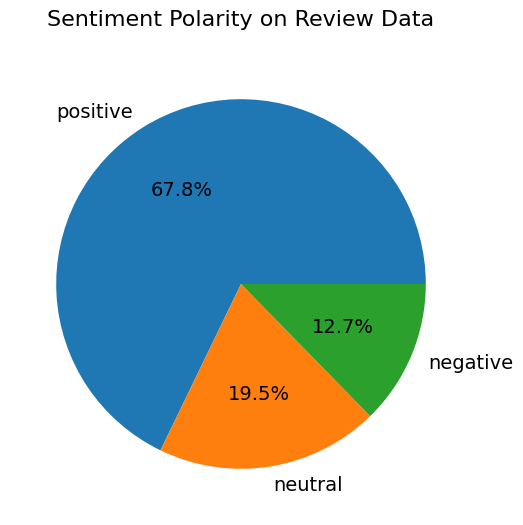

In [17]:
# Membuat Plot polarity
fig, ax = plt.subplots(figsize=(6, 6))

sizes = [count for count in clean_df['polarity'].value_counts()]

labels = list(clean_df['polarity'].value_counts().index)

explode = (0, 0, 0)

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})

ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)

plt.show()

In [18]:
# Word cloud positif
pd.set_option('display.max_colwidth', 3000)

positive_tweets = clean_df[clean_df['polarity'] == 'positive']

positive_tweets = positive_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

positive_tweets = positive_tweets.sort_values(by='polarity_score', ascending=False)

positive_tweets = positive_tweets.reset_index(drop=True)

positive_tweets.index += 1

In [19]:
# Word cloud negatif
pd.set_option('display.max_colwidth', 3000)

negative_tweets = clean_df[clean_df['polarity'] == 'negative']

negative_tweets = negative_tweets[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

negative_tweets = negative_tweets.sort_values(by='polarity_score', ascending=True)

negative_tweets = negative_tweets[0:10]

negative_tweets = negative_tweets.reset_index(drop=True)

negative_tweets.index += 1

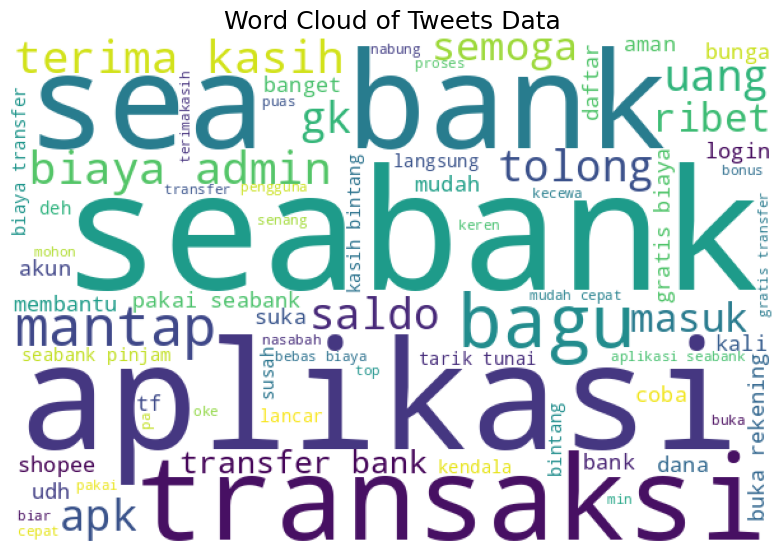

In [20]:
# Membuat string kosong 'list_words'
list_words = " ".join(
    " ".join(tweet) for tweet in clean_df['text_stopword']
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

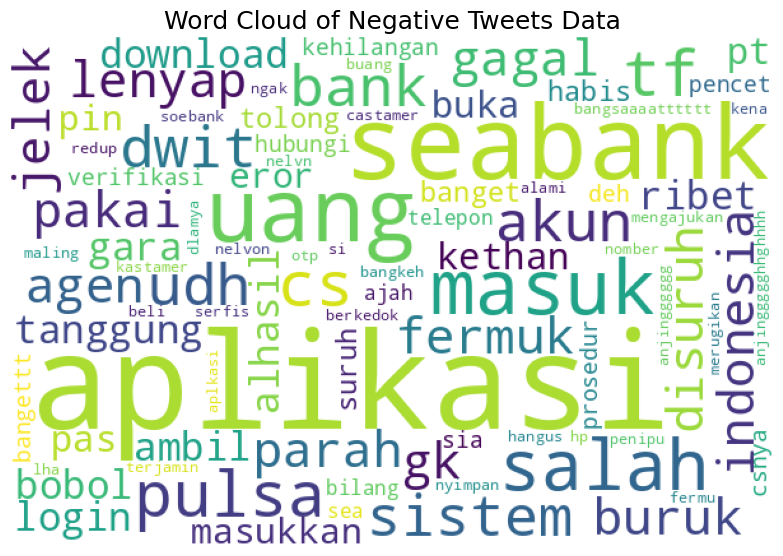

In [21]:
# Membuat string kosong 'list_words' tweet negatif.
list_words = " ".join(
    " ".join(tweet) for tweet in negative_tweets['text_stopword']
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Negative Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

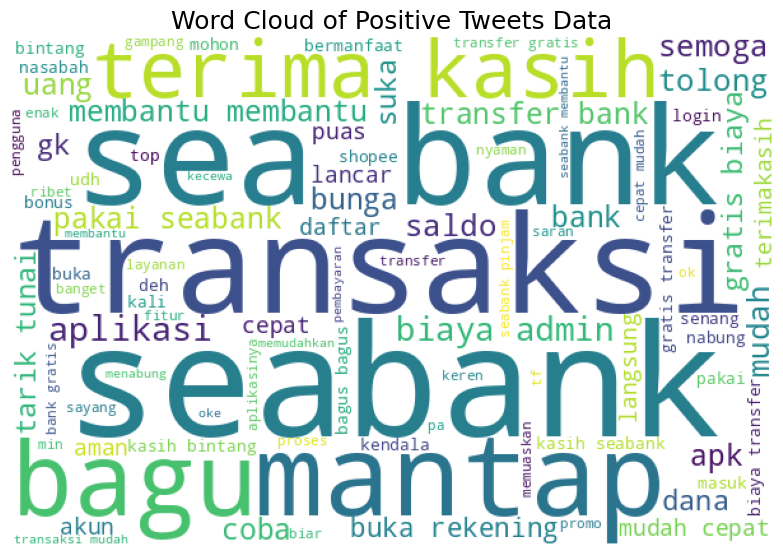

In [22]:
# Membuat string kosong 'list_words' tweet positif.
list_words = " ".join(
    " ".join(tweet) for tweet in positive_tweets['text_stopword']
)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Positive Tweets Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

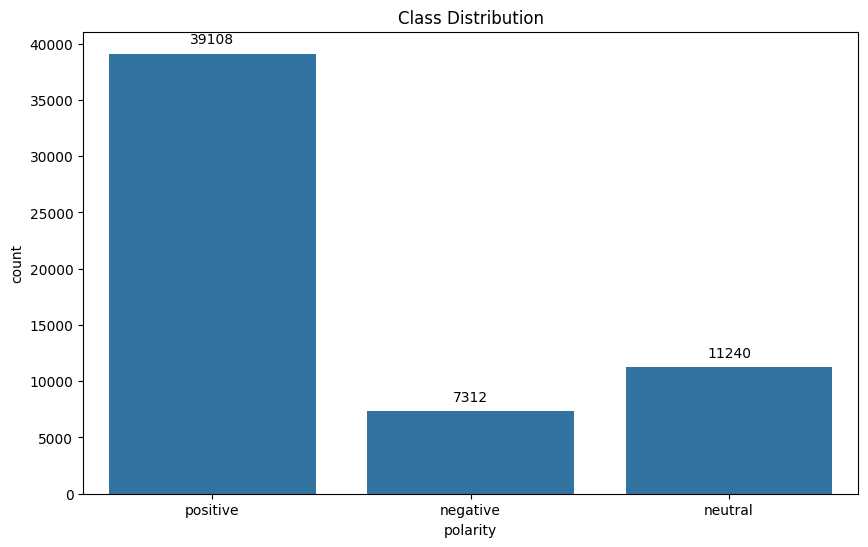

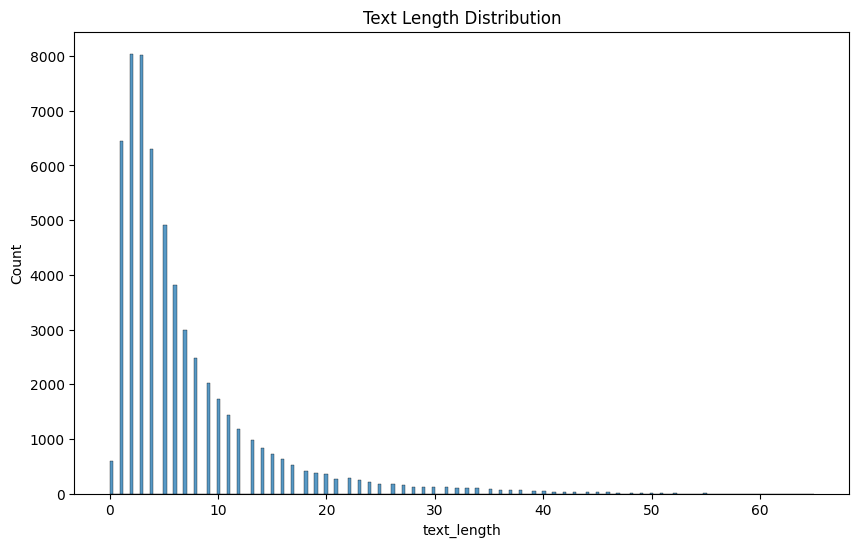

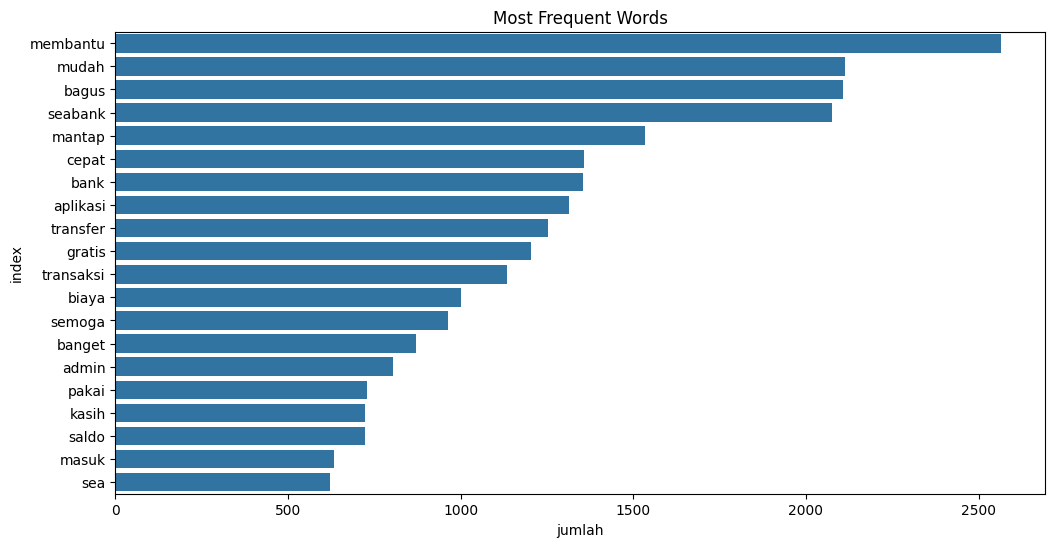

In [23]:
# Membuat Plot kelas distribusi, panjang teks, dan frekuensi kata

# class distribution
plt.figure(figsize=(10, 6))

class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

# text length distribution
plt.figure(figsize=(10, 6))

clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

# most frequent words
plt.figure(figsize=(12, 6))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

# **Label Encoding**

In [24]:
label_encoder = LabelEncoder()
clean_df['label'] = label_encoder.fit_transform(clean_df['polarity'])

# **Data Spliting**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    clean_df['text_akhir'],
    clean_df['label'],
    test_size=0.2,
    stratify=clean_df['label'],
    random_state=42
)

# **Pemodelan**

# LSTM + Embedding

In [26]:
# Feature Extraction
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [27]:
# Model LSTM
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(20000, 128, input_length=max_len),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Training LSTM
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=2,
    restore_best_weights=True
)

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 174s 521ms/step - accuracy: 0.7577 - loss: 0.6206 - val_accuracy: 0.9298 - val_loss: 0.1912
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 159s 491ms/step - accuracy: 0.9520 - loss: 0.1358 - val_accuracy: 0.9389 - val_loss: 0.1611
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 158s 484ms/step - accuracy: 0.9722 - loss: 0.0800 - val_accuracy: 0.9369 - val_loss: 0.1913
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 173s 532ms/step - accuracy: 0.9812 - loss: 0.0566 - val_accuracy: 0.9465 - val_loss: 0.1760


In [29]:
# Evaluasi Model LSTM
pred_lstm = model_lstm.predict(X_test_pad)
pred_lstm = np.argmax(pred_lstm, axis=1)

print("Accuracy LSTM:", accuracy_score(y_test, pred_lstm))
print(classification_report(y_test, pred_lstm))

361/361 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step
Accuracy LSTM: 0.9423343739160597
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1462
           1       0.84      0.89      0.86      2248
           2       0.98      0.97      0.97      7822

    accuracy                           0.94     11532
   macro avg       0.91      0.92      0.91     11532
weighted avg       0.94      0.94      0.94     11532



# **GRU + Embedding**

In [30]:
# Model GRU
model_gru = tf.keras.Sequential([
    tf.keras.layers.Embedding(20000,128),
    tf.keras.layers.GRU(128, dropout=0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training GRU
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 165s 493ms/step - accuracy: 0.7809 - loss: 0.5555 - val_accuracy: 0.9315 - val_loss: 0.1852
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 201s 492ms/step - accuracy: 0.9472 - loss: 0.1359 - val_accuracy: 0.9384 - val_loss: 0.1667
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 158s 488ms/step - accuracy: 0.9724 - loss: 0.0762 - val_accuracy: 0.9395 - val_loss: 0.1715
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 157s 481ms/step - accuracy: 0.9791 - loss: 0.0574 - val_accuracy: 0.9313 - val_loss: 0.2078


In [31]:
# Evaluasi GRU
pred_gru = model_gru.predict(X_test_pad)
pred_gru = np.argmax(pred_gru, axis=1)

print("Accuracy GRU:", accuracy_score(y_test, pred_gru))
print(classification_report(y_test, pred_gru))

361/361 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step
Accuracy GRU: 0.9413805064169268
              precision    recall  f1-score   support

           0       0.96      0.84      0.89      1462
           1       0.83      0.90      0.86      2248
           2       0.98      0.97      0.97      7822

    accuracy                           0.94     11532
   macro avg       0.92      0.90      0.91     11532
weighted avg       0.94      0.94      0.94     11532



# **CNN for Text Classification**

In [32]:
# Model CNN untuk klasifikasi teks
model_cnn = tf.keras.Sequential([
    tf.keras.layers.Embedding(20000, 128, input_length=max_len),

    tf.keras.layers.Conv1D(
        filters=128,
        kernel_size=5,
        activation='relu'
    ),

    tf.keras.layers.GlobalMaxPooling1D(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(3, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Training CNN
history_cnn = model_cnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 77s 231ms/step - accuracy: 0.7528 - loss: 0.6334 - val_accuracy: 0.9252 - val_loss: 0.2047
Epoch 2/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 75s 230ms/step - accuracy: 0.9353 - loss: 0.1821 - val_accuracy: 0.9384 - val_loss: 0.1714
Epoch 3/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 75s 231ms/step - accuracy: 0.9621 - loss: 0.1051 - val_accuracy: 0.9361 - val_loss: 0.1837
Epoch 4/10
325/325 ━━━━━━━━━━━━━━━━━━━━ 82s 231ms/step - accuracy: 0.9759 - loss: 0.0723 - val_accuracy: 0.9328 - val_loss: 0.2022


In [34]:
# Evaluasi CNN
pred_cnn = model_cnn.predict(X_test_pad)
pred_cnn = np.argmax(pred_cnn, axis=1)

print("Accuracy CNN:", accuracy_score(y_test, pred_cnn))
print(classification_report(y_test, pred_cnn))

361/361 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
Accuracy CNN: 0.9359174471037114
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      1462
           1       0.86      0.85      0.85      2248
           2       0.97      0.97      0.97      7822

    accuracy                           0.94     11532
   macro avg       0.91      0.90      0.90     11532
weighted avg       0.94      0.94      0.94     11532



# **INFERENCE**

In [35]:
# Simpan akurasi model
acc_lstm = accuracy_score(y_test, pred_lstm)
acc_gru = accuracy_score(y_test, pred_gru)
acc_cnn = accuracy_score(y_test, pred_cnn)

print("LSTM:", acc_lstm)
print("GRU :", acc_gru)
print("CNN :", acc_cnn)

LSTM: 0.9423343739160597
GRU : 0.9413805064169268
CNN : 0.9359174471037114


In [36]:
# Mengurutkan ke 3 model tersebut dengan nilai acuracy test tertinggi
models = [
    ("LSTM", acc_lstm, model_lstm),
    ("GRU", acc_gru, model_gru),
    ("CNN", acc_cnn, model_cnn)
]

sorted_models = sorted(models, key=lambda x: x[1], reverse=True)

print("=== Ranking Model ===\n")

for i, (name, acc, _) in enumerate(sorted_models, 1):
    print(f"{i}. {name} = Accuracy: {acc:.4f}")

=== Ranking Model ===

1. LSTM = Accuracy: 0.9423
2. GRU = Accuracy: 0.9414
3. CNN = Accuracy: 0.9359


In [37]:
# Ambil model terbaik
best_model_name, best_acc, best_model = sorted_models[0]

print(f"\nModel terbaik: {best_model_name}")
print(f"Test Accuracy: {best_acc:.4f}")


Model terbaik: LSTM
Test Accuracy: 0.9423


In [38]:
# fungsi pipline untuk text processing input
def preprocess_pipeline(text):

    text = cleaningText(text)
    text = casefoldingText(text)
    text = tokenizingText(text)
    text = filteringText(text)
    text = toSentence(text)
    text = stemmingText(text)

    return text

In [39]:
# Inference
kalimat_baru = input("Masukkan kalimat baru: ")

kalimat_baru_clean = preprocess_pipeline(kalimat_baru)

# tokenizing model
sequence = tokenizer.texts_to_sequences([kalimat_baru_clean])
padded = pad_sequences(sequence, maxlen=max_len)

# prediksi
pred = best_model.predict(padded)

label_index = np.argmax(pred, axis=1)[0]
confidence = np.max(pred) * 100

hasil_sentimen = label_encoder.inverse_transform([label_index])[0]

print("\n===== HASIL ANALISIS SENTIMEN =====")
print("Kalimat     :", kalimat_baru)
print("Sentimen    :", hasil_sentimen.upper())
print("Confidence  : {:.2f}%".format(confidence))

Masukkan kalimat baru: Pelayanannya sangat cepat dan memuaskan
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

===== HASIL ANALISIS SENTIMEN =====
Kalimat     : Pelayanannya sangat cepat dan memuaskan
Sentimen    : POSITIVE
Confidence  : 99.28%


In [40]:
# Inference
kalimat_baru = input("Masukkan kalimat baru: ")

kalimat_baru_clean = preprocess_pipeline(kalimat_baru)

# tokenizing model
sequence = tokenizer.texts_to_sequences([kalimat_baru_clean])
padded = pad_sequences(sequence, maxlen=max_len)

# prediksi
pred = best_model.predict(padded)

label_index = np.argmax(pred, axis=1)[0]
confidence = np.max(pred) * 100

hasil_sentimen = label_encoder.inverse_transform([label_index])[0]

print("\n===== HASIL ANALISIS SENTIMEN =====")
print("Kalimat     :", kalimat_baru)
print("Sentimen    :", hasil_sentimen.upper())
print("Confidence  : {:.2f}%".format(confidence))

Masukkan kalimat baru: Aplikasinya sering error dan bikin kesal
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

===== HASIL ANALISIS SENTIMEN =====
Kalimat     : Aplikasinya sering error dan bikin kesal
Sentimen    : NEGATIVE
Confidence  : 99.96%


In [41]:
# Inference
kalimat_baru = input("Masukkan kalimat baru: ")

kalimat_baru_clean = preprocess_pipeline(kalimat_baru)

# tokenizing model
sequence = tokenizer.texts_to_sequences([kalimat_baru_clean])
padded = pad_sequences(sequence, maxlen=max_len)

# prediksi
pred = best_model.predict(padded)

label_index = np.argmax(pred, axis=1)[0]
confidence = np.max(pred) * 100

hasil_sentimen = label_encoder.inverse_transform([label_index])[0]

print("\n===== HASIL ANALISIS SENTIMEN =====")
print("Kalimat     :", kalimat_baru)
print("Sentimen    :", hasil_sentimen.upper())
print("Confidence  : {:.2f}%".format(confidence))

Masukkan kalimat baru: Aplikasi ini saya buka setiap hari
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

===== HASIL ANALISIS SENTIMEN =====
Kalimat     : Aplikasi ini saya buka setiap hari
Sentimen    : NEUTRAL
Confidence  : 78.01%


In [43]:
!pip freeze > requirements.txt